In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold, StratifiedKFold
from scipy.stats import randint,uniform
from imblearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
data = pd.read_csv('students_dropout_academic_success.csv')
data.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


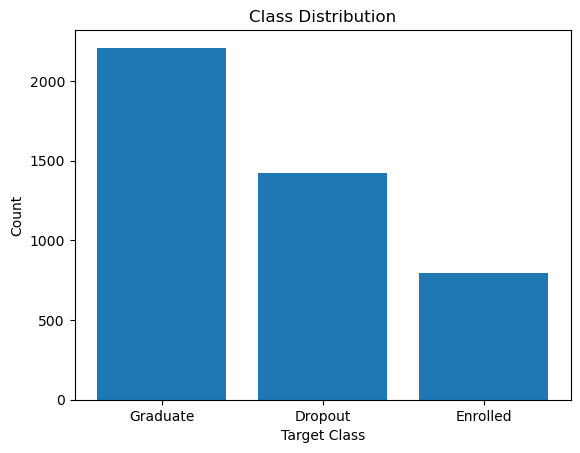

In [3]:
counts = data['target'].value_counts()
plt.bar(counts.index, counts.values)
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [4]:
data.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

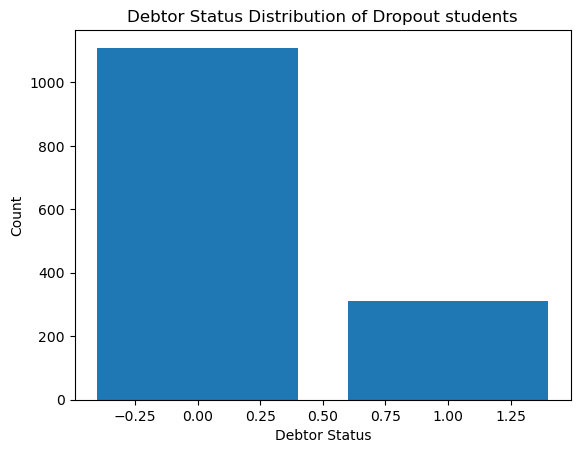

In [5]:
plt.bar(data[data['target'] == 'Dropout']['Debtor'].value_counts().index, data[data['target'] == 'Dropout']['Debtor'].value_counts().values)
plt.xlabel('Debtor Status')
plt.ylabel('Count')
plt.title('Debtor Status Distribution of Dropout students')
plt.show()

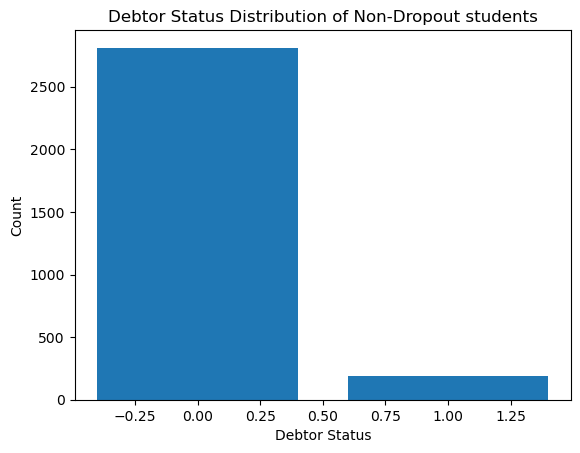

In [6]:
plt.bar(data[data['target'] != 'Dropout']['Debtor'].value_counts().index, data[data['target'] != 'Dropout']['Debtor'].value_counts().values)
plt.xlabel('Debtor Status')
plt.ylabel('Count')
plt.title('Debtor Status Distribution of Non-Dropout students')
plt.show()

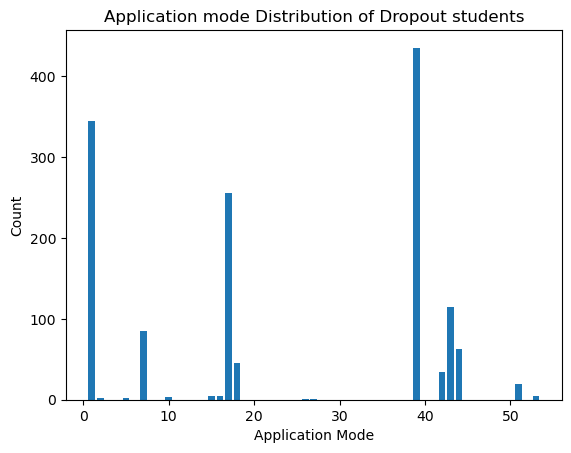

In [7]:
plt.bar(data[data['target'] == 'Dropout']['Application mode'].value_counts().index, data[data['target'] == 'Dropout']['Application mode'].value_counts().values)
plt.xlabel('Application Mode')
plt.ylabel('Count')
plt.title('Application mode Distribution of Dropout students')
plt.show()

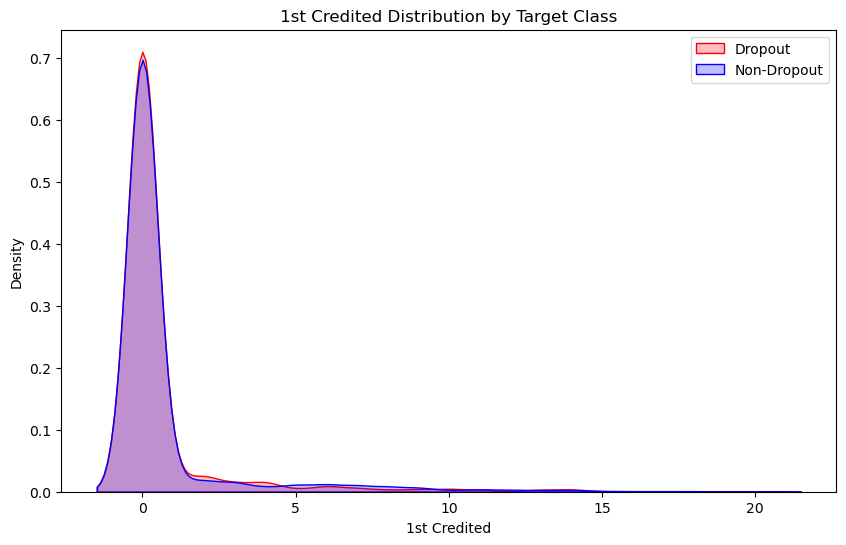

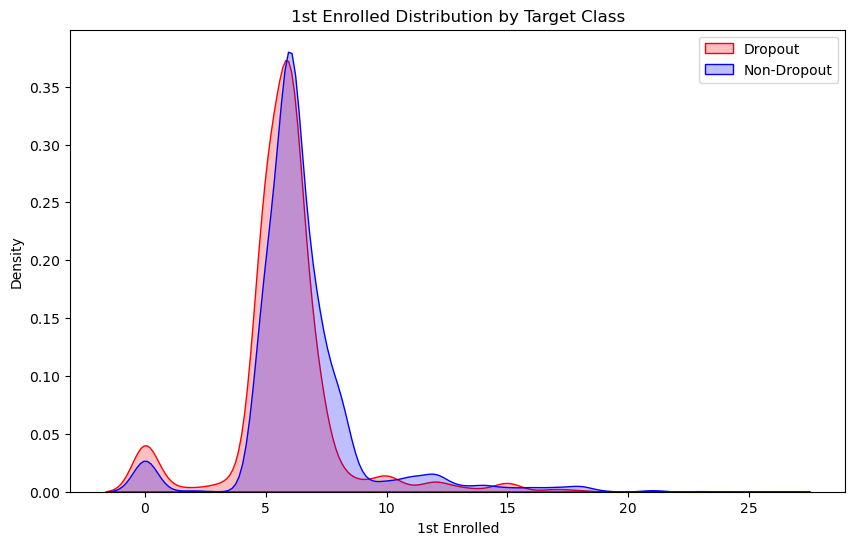

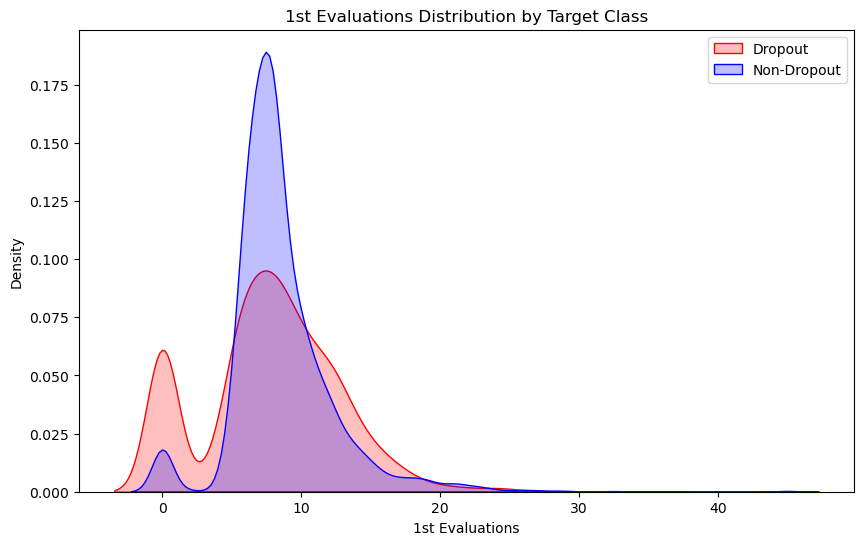

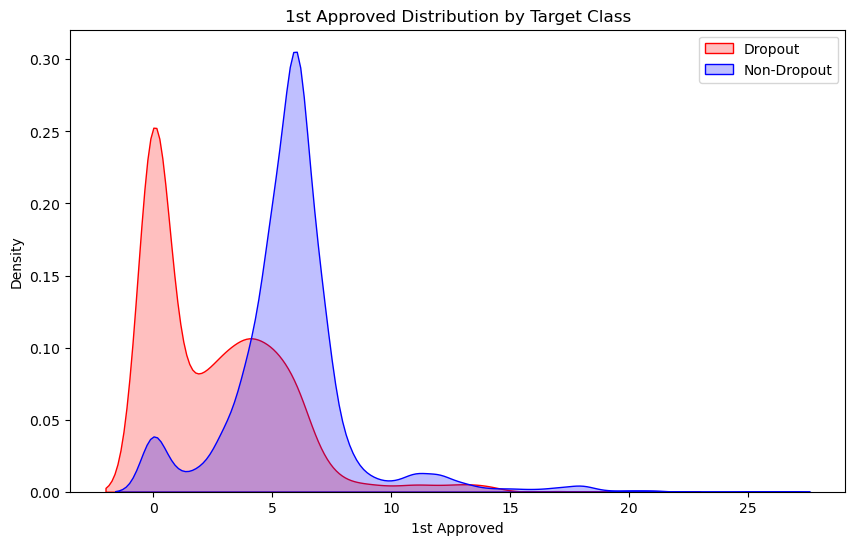

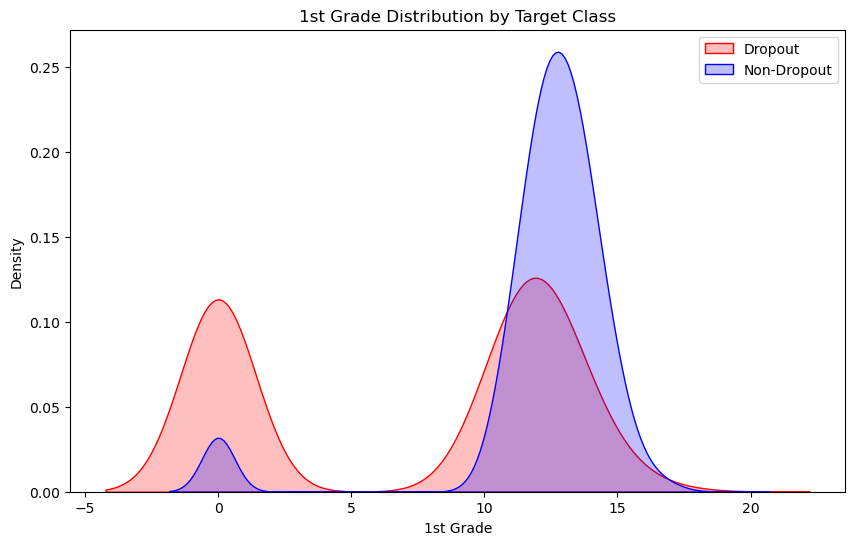

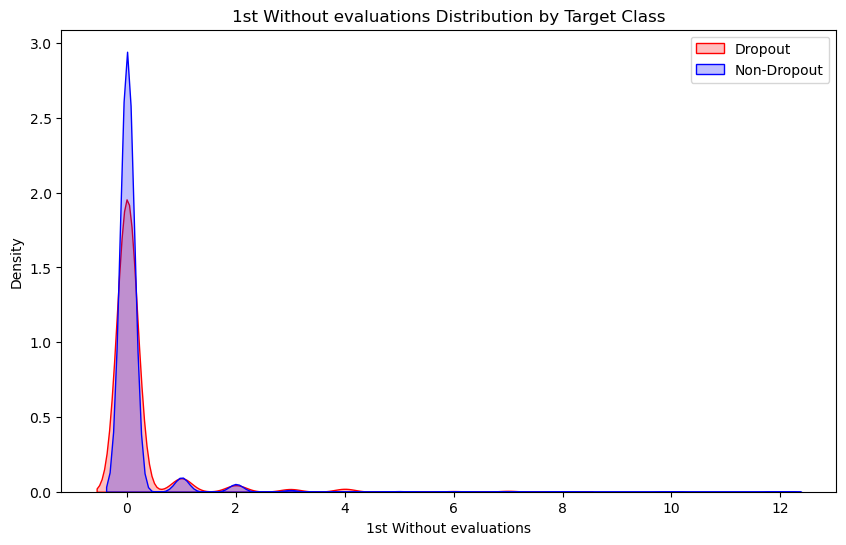

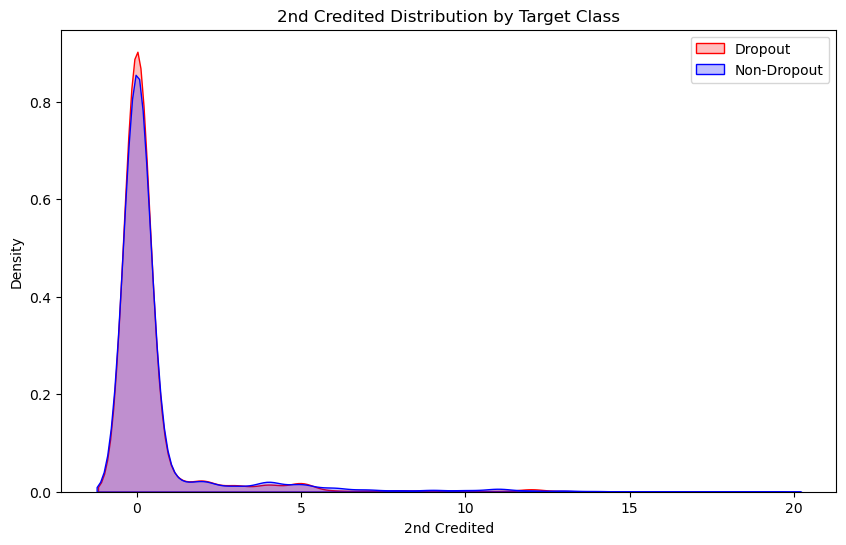

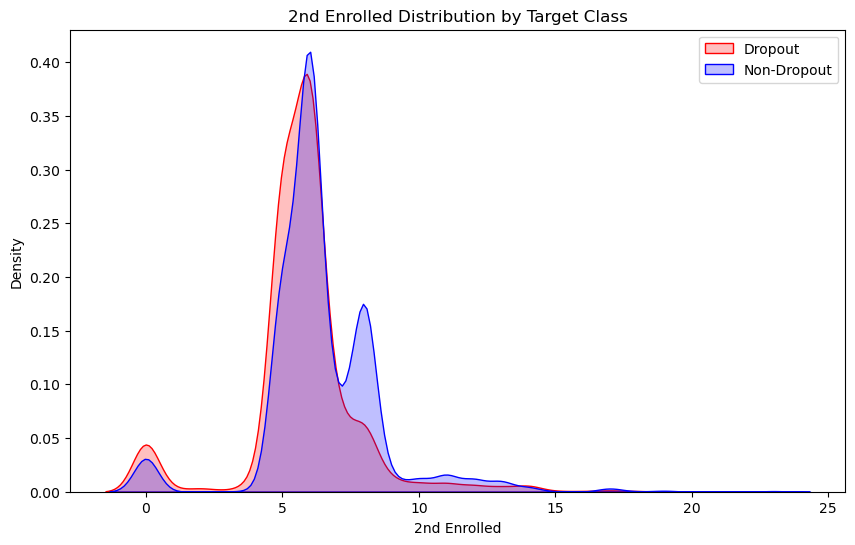

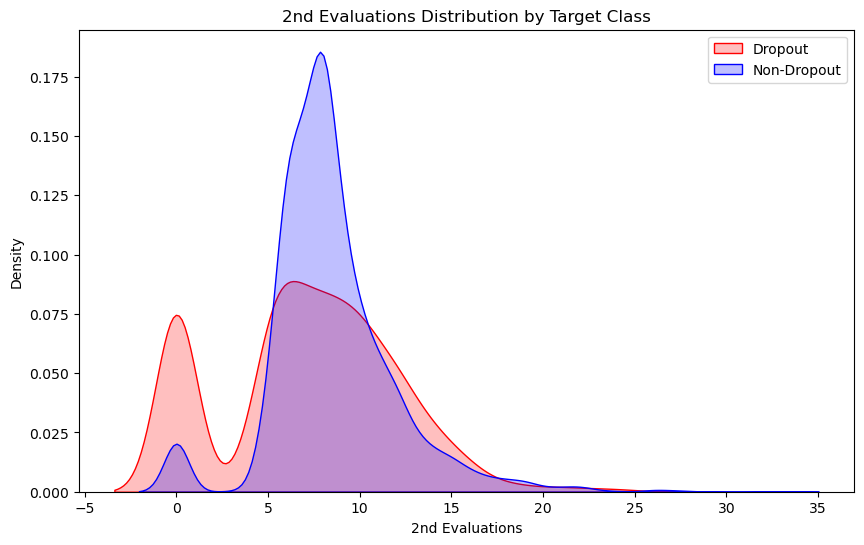

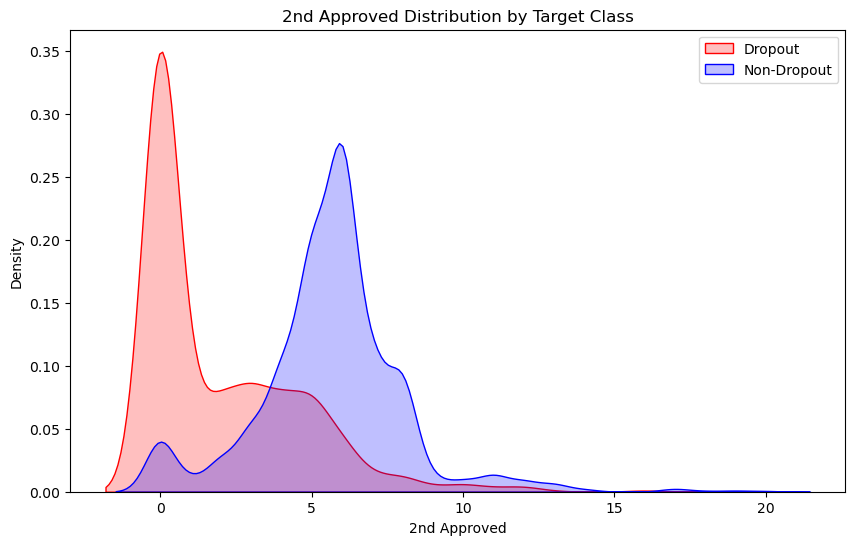

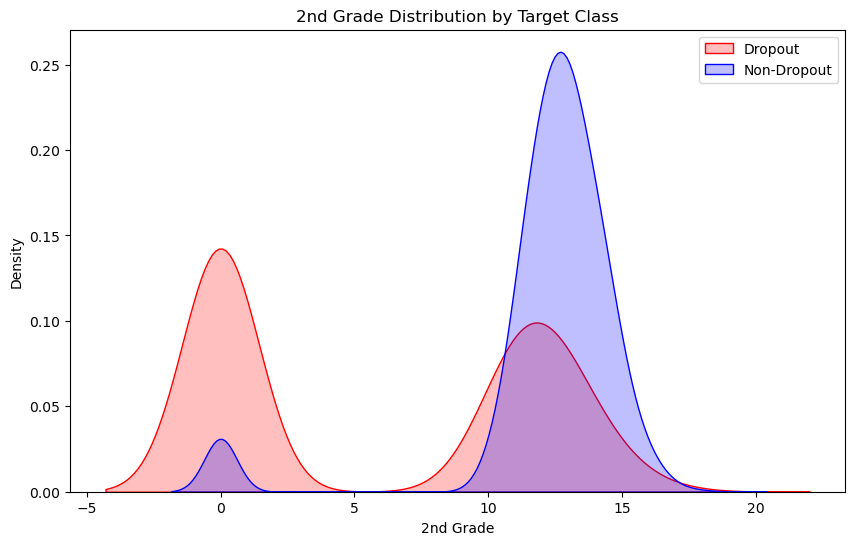

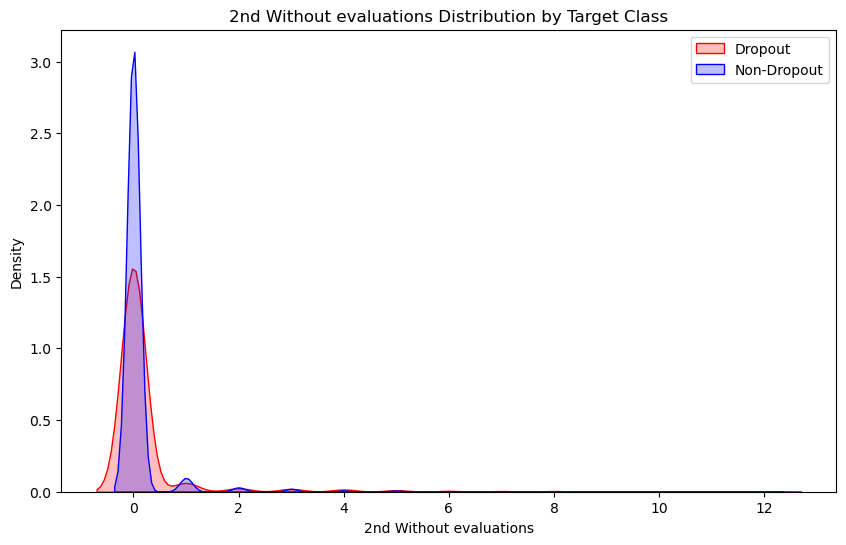

In [8]:
brac = ['credited', 'enrolled', 'evaluations', 'approved', 'grade', 'without evaluations']

for cycle in ['1st', '2nd']:
    for br in brac:
        plt.figure(figsize=(10, 6))
        sns.kdeplot(data[data['target'] == 'Dropout'][f'Curricular units {cycle} sem ({br})'], fill=True, label='Dropout', color='red')
        sns.kdeplot(data[data['target'] != 'Dropout'][f'Curricular units {cycle} sem ({br})'], fill=True, label='Non-Dropout', color='blue')
        plt.xlabel(f'{cycle.capitalize()} {br.capitalize()}')
        plt.ylabel('Density')
        plt.title(f'{cycle.capitalize()} {br.capitalize()} Distribution by Target Class')
        plt.legend()
        plt.show()

In [9]:
avg_grade = (data['Curricular units 1st sem (grade)']+data['Curricular units 2nd sem (grade)'])/2
avg_grade.name = 'Average Grade'
avg_grade

0        0.000000
1       13.833333
2        0.000000
3       12.914286
4       12.666667
          ...    
4419    13.133333
4420    11.500000
4421    14.206250
4422    12.900000
4423    12.333333
Name: Average Grade, Length: 4424, dtype: float64

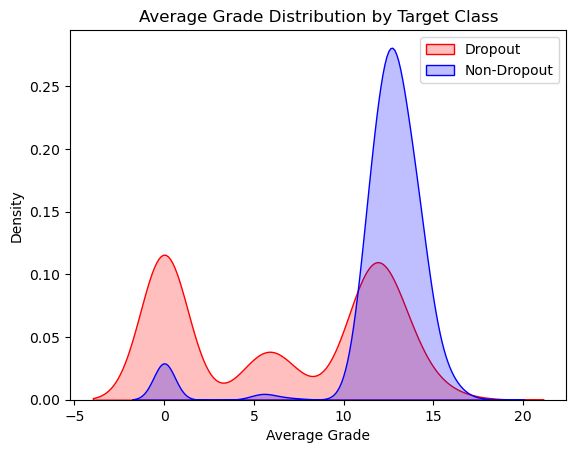

In [10]:
data_new = data.copy()
data_new['Average Grade'] = avg_grade
sns.kdeplot(data_new[data_new['target'] == 'Dropout']['Average Grade'], fill=True, label='Dropout', color='red')
sns.kdeplot(data_new[data_new['target'] != 'Dropout']['Average Grade'], fill=True, label='Non-Dropout', color='blue')
plt.xlabel('Average Grade')
plt.ylabel('Density')
plt.title('Average Grade Distribution by Target Class')
plt.legend()
plt.show()

In [11]:
data_new[data_new['target'] == 'Dropout']['Average Grade'].describe()

count    1421.000000
mean        6.577997
std         5.660310
min         0.000000
25%         0.000000
50%         6.500000
75%        11.857143
max        17.166667
Name: Average Grade, dtype: float64

In [12]:
data_new[data_new['target'] != 'Dropout']['Average Grade'].describe()

count    3003.000000
mean       12.260865
std         2.945648
min         0.000000
25%        11.857143
50%        12.733333
75%        13.638112
max        18.283654
Name: Average Grade, dtype: float64

In [13]:
features = []
for col in data_new.columns:
    if col not in ['target','Unemployment rate', 'Inflation rate']:
        features.append(col)

Graduate & Enrolled vs Dropout

In [14]:
X_1 = data_new[features].copy()
y_1 = data_new['target'].copy()
y_1[y_1 != 'Dropout'] = 'Non-Dropout'
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=42, stratify=y_1)

Graduate vs Dropout

In [15]:
X_2 = data_new[(data_new['target'] == 'Dropout') | (data_new['target'] == 'Graduate')][features].copy()
y_2 = data_new[(data_new['target'] == 'Dropout') | (data_new['target'] == 'Graduate')]['target'].copy()
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=42, stratify=y_2)

Graduate vs Dropout vs Enrolled

In [16]:
X_3 = data_new[features].copy()
y_3 = data_new['target'].copy()
X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, y_3, test_size=0.2, random_state=42, stratify=y_3)

<h1>Random Forest Classifier with RandomizedSearchCV</h1>

<h4> Check for 2 class (Graduate & Enrolled vs Dropout) </h4>

In [42]:
y_train_1_enc = y_train_1.copy()
y_train_1_enc = y_train_1_enc.apply(lambda x: 1 if x == 'Dropout' else 0)
y_test_1_enc = y_test_1.copy()
y_test_1_enc = y_test_1_enc.apply(lambda x: 1 if x == 'Dropout' else 0)
y_train_2_enc = y_train_2.copy()
y_train_2_enc = y_train_2_enc.apply(lambda x: 1 if x == 'Dropout' else 0)
y_test_2_enc = y_test_2.copy()
y_test_2_enc = y_test_2_enc.apply(lambda x: 1 if x == 'Dropout' else 0)

In [43]:
forest = RandomForestClassifier(random_state=42)
forest_pipeline = Pipeline(
    [
        ('smote', SMOTE(random_state=42)),
        ('forest', forest)
    ]
)
param_dist = {
    'forest__n_estimators': randint(100, 500),
    'forest__max_depth': [None] + list(np.arange(5, 30)),
    'forest__min_samples_split': randint(2, 10),
    'forest__min_samples_leaf': randint(1, 10),
    'forest__max_features': ['sqrt', 'log2',None],
    'forest__bootstrap': [True, False],
    'forest__class_weight': ['balanced', 'balanced_subsample', None]
}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
forest_cv = RandomizedSearchCV(estimator=forest_pipeline, param_distributions=param_dist, n_iter=100, cv=kf, scoring='f1', random_state=42, n_jobs=-1)
forest_cv.fit(X_train_1, y_train_1_enc)
print("Best parameters for Random Forest:", forest_cv.best_params_)
print("Best Score: ", forest_cv.best_score_)

Best parameters for Random Forest: {'forest__bootstrap': True, 'forest__class_weight': 'balanced', 'forest__max_depth': 15, 'forest__max_features': 'sqrt', 'forest__min_samples_leaf': 1, 'forest__min_samples_split': 3, 'forest__n_estimators': 221}
Best Score:  0.7995929395041003


Random Forest Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.77      0.79       284
 Non-Dropout       0.89      0.92      0.91       601

    accuracy                           0.87       885
   macro avg       0.86      0.84      0.85       885
weighted avg       0.87      0.87      0.87       885



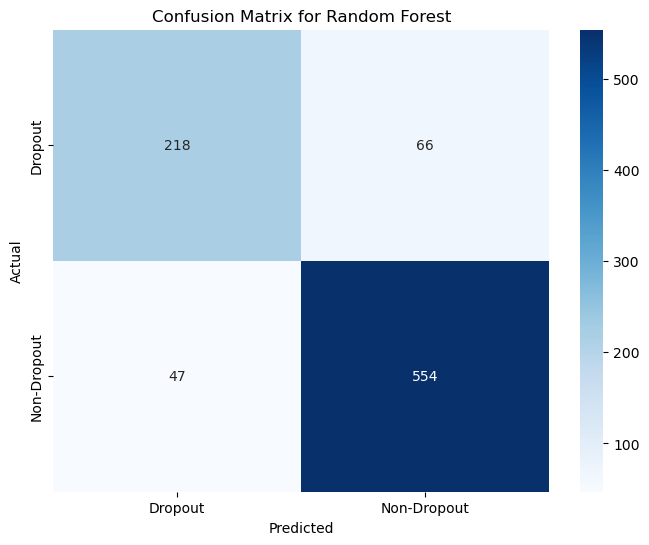

In [44]:
forest_best = forest_cv.best_estimator_
y_pred_forest = forest_best.predict(X_test_1)
y_pred_forest = np.where(y_pred_forest == 1, 'Dropout', 'Non-Dropout')
print("Random Forest Classification Report:")
print(classification_report(y_test_1, y_pred_forest))
cm_forest = confusion_matrix(y_test_1, y_pred_forest)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_forest, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Non-Dropout'], yticklabels=['Dropout', 'Non-Dropout'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()

<h4> Check for 3 class </h4>

In [45]:
cv_3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
forest_cv_3 = RandomizedSearchCV(estimator=forest_pipeline, param_distributions=param_dist, n_iter=100, cv=cv_3, scoring='f1_macro', random_state=42, n_jobs=-1)
forest_cv_3.fit(X_train_3, y_train_3)
print("Best parameters for Random Forest:", forest_cv_3.best_params_)
print("Best Score: ", forest_cv_3.best_score_)

Best parameters for Random Forest: {'forest__bootstrap': False, 'forest__class_weight': 'balanced', 'forest__max_depth': None, 'forest__max_features': 'sqrt', 'forest__min_samples_leaf': 9, 'forest__min_samples_split': 5, 'forest__n_estimators': 332}
Best Score:  0.7192566471427492


Random Forest Classification Report for 3 classes:
              precision    recall  f1-score   support

     Dropout       0.83      0.67      0.74       284
    Enrolled       0.45      0.58      0.50       159
    Graduate       0.84      0.85      0.85       442

    accuracy                           0.75       885
   macro avg       0.70      0.70      0.70       885
weighted avg       0.77      0.75      0.75       885



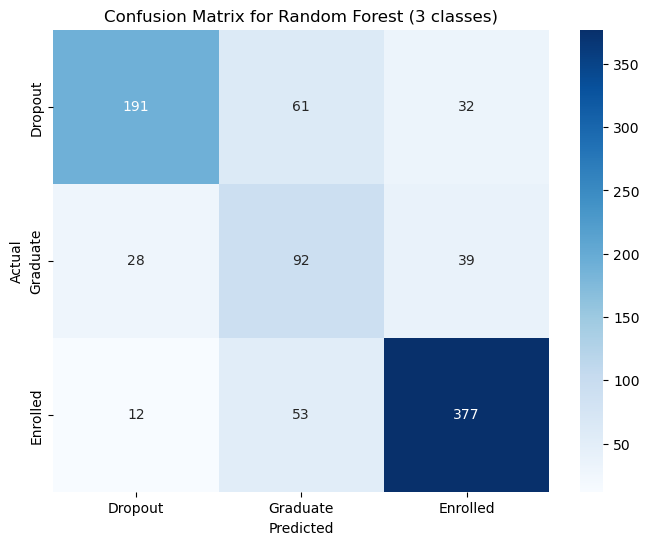

In [46]:
forest_best_3 = forest_cv_3.best_estimator_
y_pred_forest_3 = forest_best_3.predict(X_test_3)
print("Random Forest Classification Report for 3 classes:")
print(classification_report(y_test_3, y_pred_forest_3))
cm_forest_3 = confusion_matrix(y_test_3, y_pred_forest_3)   
plt.figure(figsize=(8, 6))
sns.heatmap(cm_forest_3, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Graduate', 'Enrolled'], yticklabels=['Dropout', 'Graduate', 'Enrolled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest (3 classes)')
plt.show()

<h4> Check for 2 class (Graduate vs Dropout)[Excluded Enrolled] </h4>

In [47]:
forest_cv_2 = RandomizedSearchCV(estimator=forest_pipeline, param_distributions=param_dist, n_iter=100, cv=cv_3, scoring='f1', random_state=42, n_jobs=-1)
forest_cv_2.fit(X_train_2, y_train_2_enc)
print("Best parameters for Random Forest:", forest_cv_2.best_params_)
print("Best Score: ", forest_cv_2.best_score_)

Best parameters for Random Forest: {'forest__bootstrap': False, 'forest__class_weight': 'balanced', 'forest__max_depth': 23, 'forest__max_features': 'sqrt', 'forest__min_samples_leaf': 1, 'forest__min_samples_split': 3, 'forest__n_estimators': 151}
Best Score:  0.8759849789511716


Random Forest Classification Report for 2 classes:
              precision    recall  f1-score   support

     Dropout       0.94      0.83      0.88       284
    Graduate       0.90      0.97      0.93       442

    accuracy                           0.91       726
   macro avg       0.92      0.90      0.91       726
weighted avg       0.92      0.91      0.91       726



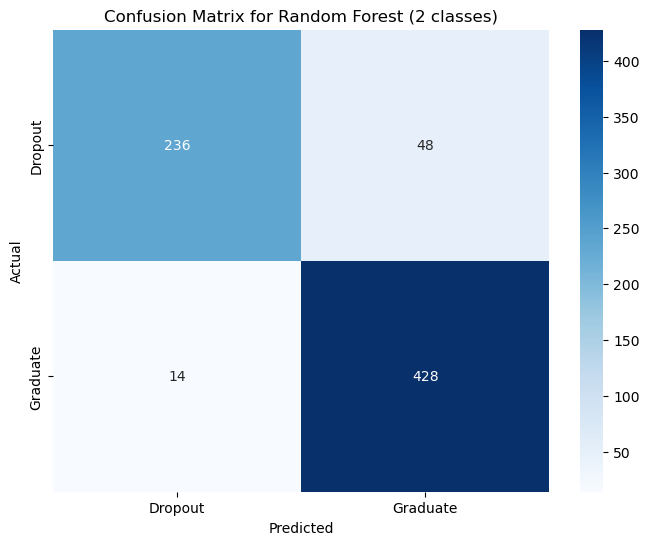

In [48]:
forest_best2 = forest_cv_2.best_estimator_
y_pred_forest_2 = forest_best2.predict(X_test_2)
y_pred_forest_2 = np.where(y_pred_forest_2 == 1, 'Dropout', 'Graduate')
print("Random Forest Classification Report for 2 classes:")
print(classification_report(y_test_2, y_pred_forest_2))
cm_forest_2 = confusion_matrix(y_test_2, y_pred_forest_2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_forest_2, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Graduate'], yticklabels=['Dropout', 'Graduate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest (2 classes)')
plt.show()

<h1> XGBoost Classifier </h1>

<h4>Graduate & Enrolled vs Dropout </h4>

In [ ]:
xgb = XGBClassifier(random_state=42)
xgb_pipeline = Pipeline(
    [
        ('smote', SMOTE(random_state=42)),
        ('xgb', xgb)]
)
param_dist_xgb = {
    'xgb__n_estimators': randint(100, 500),
    'xgb__max_depth': randint(3, 10),
    'xgb__learning_rate': uniform(0.01, 0.3),
    'xgb__subsample': uniform(0.6, 0.4),
    'xgb__colsample_bytree': uniform(0.6, 0.4),
    'xgb__gamma': uniform(0, 0.5),
    'xgb__reg_alpha': uniform(0, 1),  # L1 regularization
    'xgb__reg_lambda': uniform(0, 1),  # L2 regularization
}
kf_xgb = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_cv = RandomizedSearchCV(estimator=xgb_pipeline, param_distributions=param_dist_xgb, n_iter=150, cv=kf_xgb, scoring='f1', random_state=42, n_jobs=-1)
xgb_cv.fit(X_train_1, y_train_1_enc)
print("Best parameters for XGBoost:", xgb_cv.best_params_)
print("Best Score: ", xgb_cv.best_score_)

Best parameters for XGBoost: {'xgb__colsample_bytree': 0.7154522212961023, 'xgb__gamma': 0.29061911071130614, 'xgb__learning_rate': 0.0563088145822607, 'xgb__max_depth': 6, 'xgb__n_estimators': 432, 'xgb__reg_alpha': 0.5325894325515859, 'xgb__reg_lambda': 0.05182353682242691, 'xgb__subsample': 0.7346417112775683}
Best Score:  0.8023343418706638


XGBoost Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.76      0.79       284
 Non-Dropout       0.89      0.93      0.91       601

    accuracy                           0.87       885
   macro avg       0.86      0.84      0.85       885
weighted avg       0.87      0.87      0.87       885



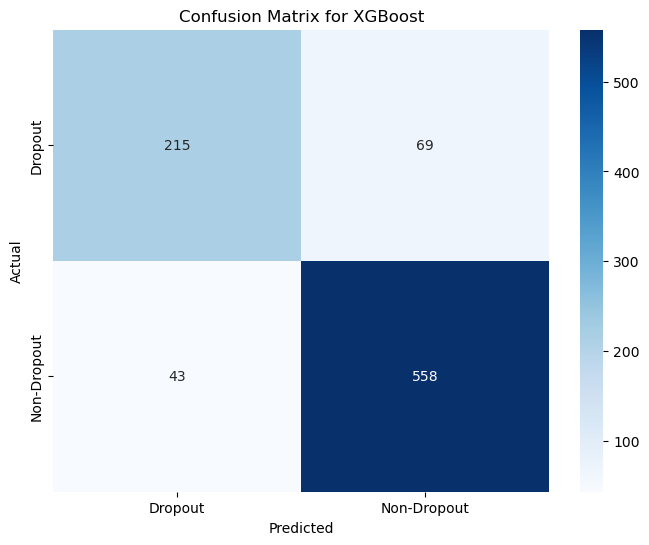

In [50]:
xgb_best = xgb_cv.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_1)
y_pred_xgb = np.where(y_pred_xgb == 1, 'Dropout', 'Non-Dropout')
print("XGBoost Classification Report:")
print(classification_report(y_test_1, y_pred_xgb))
cm_xgb = confusion_matrix(y_test_1, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Non-Dropout'], yticklabels=['Dropout', 'Non-Dropout'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost')
plt.show()

<h4> Graduate vs Enrolled vs Dropout </h4>

In [52]:
le = LabelEncoder()
y_train_3_enc = y_train_3.copy()
y_train_3_enc = le.fit_transform(y_train_3_enc)
y_test_3_enc = y_test_3.copy()
y_test_3_enc = le.transform(y_test_3_enc)

xgb_cv_2 = RandomizedSearchCV(estimator=xgb_pipeline, param_distributions=param_dist_xgb, n_iter=150, cv=kf_xgb, scoring='f1_macro', random_state=42, n_jobs=-1)
xgb_cv_2.fit(X_train_3, y_train_3_enc)
print("Best parameters for XGBoost (3 classes):", xgb_cv_2.best_params_)
print("Best Score: ", xgb_cv_2.best_score_)

Best parameters for XGBoost (3 classes): {'xgb__colsample_bytree': 0.6588293923716152, 'xgb__gamma': 0.4632938125807472, 'xgb__learning_rate': 0.15763488792386146, 'xgb__max_depth': 6, 'xgb__n_estimators': 439, 'xgb__reg_alpha': 0.4591357562382613, 'xgb__reg_lambda': 0.980032575285477, 'xgb__subsample': 0.7970472375971478}
Best Score:  0.7338545130984516


XGBoost Classification Report for 3 classes:
              precision    recall  f1-score   support

     Dropout       0.80      0.73      0.76       284
    Enrolled       0.47      0.50      0.49       159
    Graduate       0.84      0.87      0.86       442

    accuracy                           0.76       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.76      0.76      0.76       885



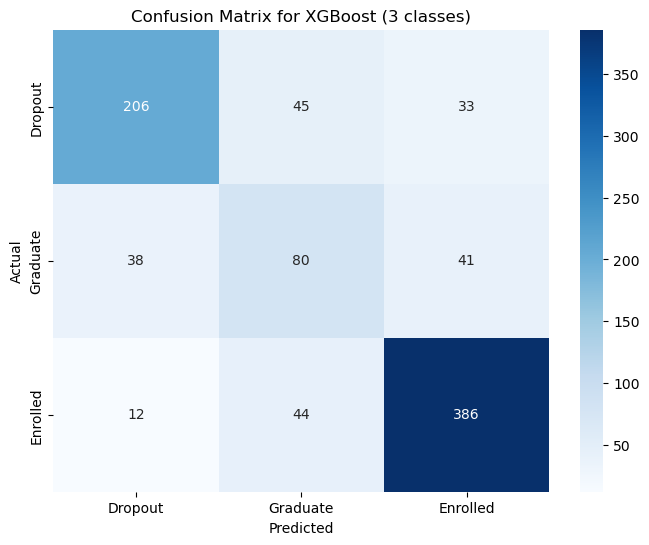

In [53]:
xgb_best_3 = xgb_cv_2.best_estimator_
y_pred_xgb_3 = xgb_best_3.predict(X_test_3)
y_pred_xgb_3 = le.inverse_transform(y_pred_xgb_3)
print("XGBoost Classification Report for 3 classes:")
print(classification_report(y_test_3, y_pred_xgb_3))
cm_xgb_3 = confusion_matrix(y_test_3, y_pred_xgb_3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_3, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Graduate', 'Enrolled'], yticklabels=['Dropout', 'Graduate', 'Enrolled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost (3 classes)')
plt.show()

<h4>Graduated vs Dropout </h4>

In [54]:
xgb_cv_2 = RandomizedSearchCV(estimator=xgb_pipeline, param_distributions=param_dist_xgb, n_iter=150, cv=kf_xgb, scoring='f1', random_state=42, n_jobs=-1)
xgb_cv_2.fit(X_train_2, y_train_2_enc)
print("Best parameters for XGBoost (2 classes):", xgb_cv_2.best_params_)
print("Best Score: ", xgb_cv_2.best_score_)

Best parameters for XGBoost (2 classes): {'xgb__colsample_bytree': 0.6748174994230093, 'xgb__gamma': 0.16183961820212184, 'xgb__learning_rate': 0.13763093158492504, 'xgb__max_depth': 3, 'xgb__n_estimators': 119, 'xgb__reg_alpha': 0.24240973241508024, 'xgb__reg_lambda': 0.11483682473920354, 'xgb__subsample': 0.8442480169766531}
Best Score:  0.8822348804930794


XGBoost Classification Report for 2 classes:
              precision    recall  f1-score   support

     Dropout       0.92      0.83      0.87       284
    Graduate       0.90      0.95      0.92       442

    accuracy                           0.90       726
   macro avg       0.91      0.89      0.90       726
weighted avg       0.90      0.90      0.90       726



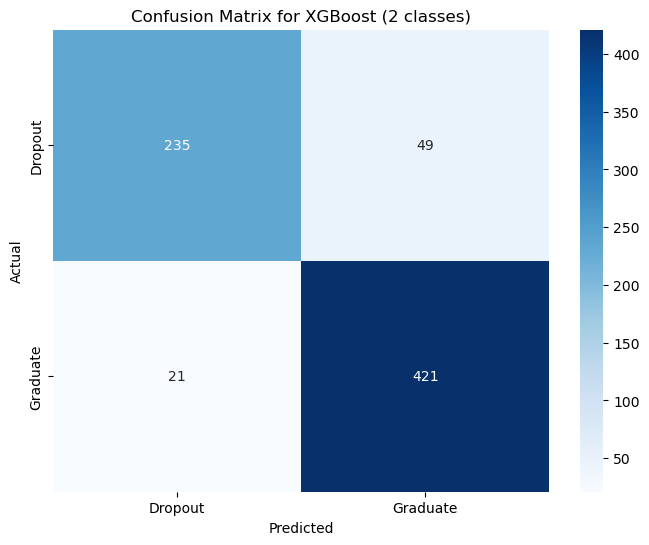

In [55]:
xgb_best_2 = xgb_cv_2.best_estimator_
y_pred_xgb_2 = xgb_best_2.predict(X_test_2)
y_pred_xgb_2 = np.where(y_pred_xgb_2 == 1, 'Dropout', 'Graduate')
print("XGBoost Classification Report for 2 classes:")
print(classification_report(y_test_2, y_pred_xgb_2))
cm_xgb_2 = confusion_matrix(y_test_2, y_pred_xgb_2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_2, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Graduate'], yticklabels=['Dropout', 'Graduate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for XGBoost (2 classes)')
plt.show()

<h1> SVM </h1>

<h4> Graduated & Enrolled vs Dropout </h4>

In [64]:
svm = SVC(random_state=42)
svm_pipeline = Pipeline(
    [
        ('smote', SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('svm', svm)
    ]
)
param_dist_svm = {
    'svm__C': uniform(0.1, 10),
    'svm__kernel': ['linear', 'rbf', 'poly'],
    'svm__degree': randint(2, 4),
    'svm__gamma': ['scale', 'auto'] + list(np.arange(0.01, 1.01, 0.01)),
    'svm__class_weight': ['balanced', None]
}
kf_svm = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
svm_cv = RandomizedSearchCV(estimator=svm_pipeline, param_distributions=param_dist_svm, n_iter=100, cv=kf_svm, scoring='f1', random_state=42, n_jobs=-1)
svm_cv.fit(X_train_1, y_train_1_enc)
print("Best parameters for SVM:", svm_cv.best_params_)
print("Best Score: ", svm_cv.best_score_)

Best parameters for SVM: {'svm__C': 0.19197051616629648, 'svm__class_weight': None, 'svm__degree': 2, 'svm__gamma': 0.97, 'svm__kernel': 'linear'}
Best Score:  0.7844293092282737


SVM Classification Report:
              precision    recall  f1-score   support

     Dropout       0.83      0.75      0.79       284
 Non-Dropout       0.89      0.93      0.91       601

    accuracy                           0.87       885
   macro avg       0.86      0.84      0.85       885
weighted avg       0.87      0.87      0.87       885



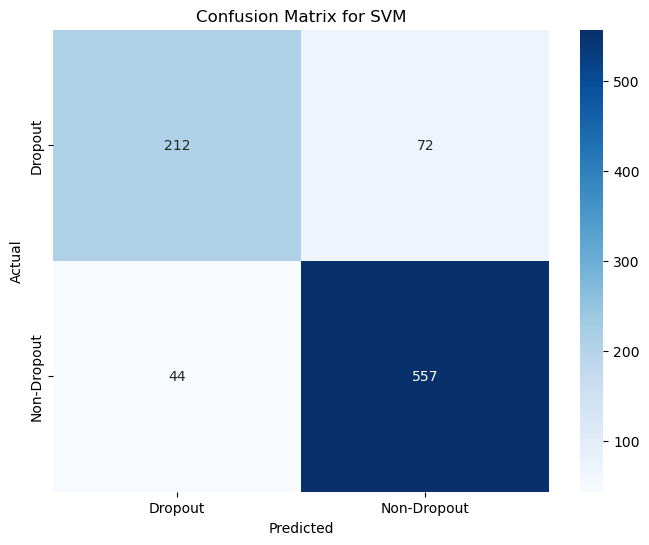

In [66]:
svm_best = svm_cv.best_estimator_
y_pred_svm = svm_best.predict(X_test_1)
y_pred_svm = np.where(y_pred_svm == 1, 'Dropout', 'Non-Dropout')
print("SVM Classification Report:")
print(classification_report(y_test_1, y_pred_svm))
cm_svm = confusion_matrix(y_test_1, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Non-Dropout'], yticklabels=['Dropout', 'Non-Dropout'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM')
plt.show()

<h4> Graduate vs Enroll vs Dropout </h4>

In [68]:
svm_cv_2 = RandomizedSearchCV(estimator=svm_pipeline, param_distributions=param_dist_svm, n_iter=100, cv=kf_svm, scoring='f1_macro', random_state=42, n_jobs=-1)
svm_cv_2.fit(X_train_3, y_train_3_enc)
print("Best parameters for SVM (3 classes):", svm_cv_2.best_params_)
print("Best Score: ", svm_cv_2.best_score_)

Best parameters for SVM (3 classes): {'svm__C': 3.592095746126609, 'svm__class_weight': None, 'svm__degree': 3, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Best Score:  0.6986328365568242


SVM Classification Report for 3 classes:
              precision    recall  f1-score   support

     Dropout       0.82      0.69      0.75       284
    Enrolled       0.42      0.57      0.48       159
    Graduate       0.83      0.81      0.82       442

    accuracy                           0.73       885
   macro avg       0.69      0.69      0.68       885
weighted avg       0.75      0.73      0.74       885



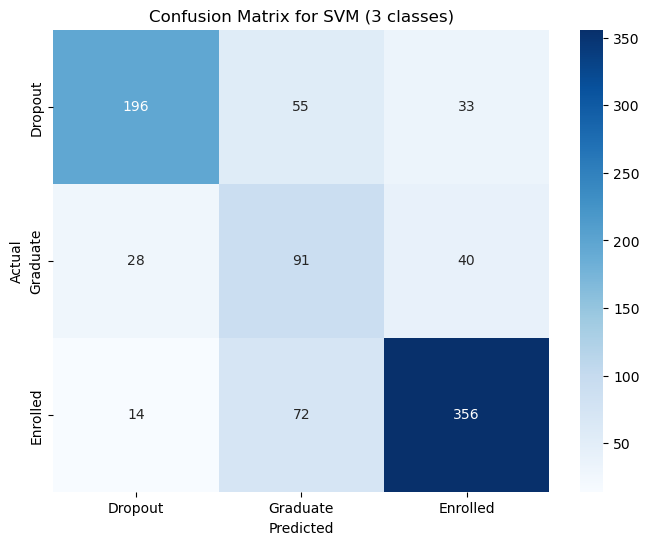

In [69]:
svm_best_3 = svm_cv_2.best_estimator_
y_pred_svm_3 = svm_best_3.predict(X_test_3)
y_pred_svm_3 = le.inverse_transform(y_pred_svm_3)
print("SVM Classification Report for 3 classes:")
print(classification_report(y_test_3, y_pred_svm_3))
cm_svm_3 = confusion_matrix(y_test_3, y_pred_svm_3)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_3, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Graduate', 'Enrolled'], yticklabels=['Dropout', 'Graduate', 'Enrolled'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM (3 classes)')
plt.show()

<h4> Graduate vs Dropout </h4>

In [71]:
svm_cv_2 = RandomizedSearchCV(estimator=svm_pipeline, param_distributions=param_dist_svm, n_iter=100, cv=kf_svm, scoring='f1', random_state=42, n_jobs=-1)
svm_cv_2.fit(X_train_2, y_train_2_enc)
print("Best parameters for SVM (2 classes):", svm_cv_2.best_params_)
print("Best Score: ", svm_cv_2.best_score_)

Best parameters for SVM (2 classes): {'svm__C': 0.4142918568673425, 'svm__class_weight': 'balanced', 'svm__degree': 2, 'svm__gamma': 0.5, 'svm__kernel': 'linear'}
Best Score:  0.8767400786291265


SVM Classification Report for 2 classes:
              precision    recall  f1-score   support

     Dropout       0.92      0.85      0.88       284
    Graduate       0.91      0.95      0.93       442

    accuracy                           0.91       726
   macro avg       0.91      0.90      0.91       726
weighted avg       0.91      0.91      0.91       726



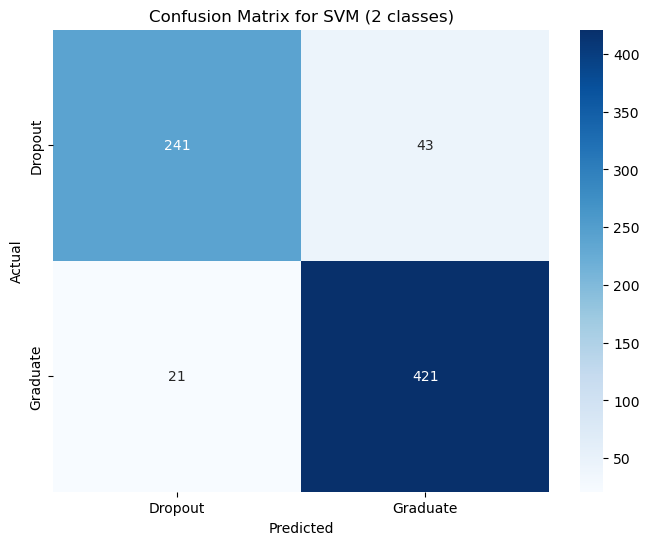

In [72]:
svm_best_2 = svm_cv_2.best_estimator_
y_pred_svm_2 = svm_best_2.predict(X_test_2)
y_pred_svm_2 = np.where(y_pred_svm_2 == 1, 'Dropout', 'Graduate')
print("SVM Classification Report for 2 classes:")
print(classification_report(y_test_2, y_pred_svm_2))
cm_svm_2 = confusion_matrix(y_test_2, y_pred_svm_2)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm_2, annot=True, fmt='d', cmap='Blues', xticklabels=['Dropout', 'Graduate'], yticklabels=['Dropout', 'Graduate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM (2 classes)')
plt.show()